In [ ]:
pip install yfinance

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas_datareader import data as pdr
import yfinance as yfin
yfin.pdr_override()

In [ ]:
start = '2015-09-01'
end = '2023-03-02'

df = pdr.get_data_yahoo('ETH-USD', start, end)
df.head()

[*********************100%***********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2017-11-09,308.644989,329.451996,307.056000,320.884003,320.884003,893249984
2017-11-10,320.670990,324.717987,294.541992,299.252991,299.252991,885985984
2017-11-11,298.585999,319.453003,298.191986,314.681000,314.681000,842300992
2017-11-12,314.690002,319.153015,298.513000,307.907990,307.907990,1613479936
2017-11-13,307.024994,328.415009,307.024994,316.716003,316.716003,1041889984


In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
scaler = MinMaxScaler(feature_range=(0,1))


In [ ]:
df

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2017-11-09,308.644989,329.451996,307.056000,320.884003,320.884003,893249984
2017-11-10,320.670990,324.717987,294.541992,299.252991,299.252991,885985984
2017-11-11,298.585999,319.453003,298.191986,314.681000,314.681000,842300992
2017-11-12,314.690002,319.153015,298.513000,307.907990,307.907990,1613479936
2017-11-13,307.024994,328.415009,307.024994,316.716003,316.716003,1041889984
...,...,...,...,...,...,...
2023-02-25,1608.658325,1608.865112,1567.631714,1594.914917,1594.914917,5657686235
2023-02-26,1594.761108,1645.273438,1590.393066,1640.817139,1640.817139,5727967432
2023-02-27,1640.763672,1662.575684,1615.387939,1634.326416,1634.326416,7239824677


In [ ]:
df = df.reset_index()
df = df.drop(['Date','Adj Close'], axis = 1)

In [ ]:
data_training = pd.DataFrame(df['Close'][0:int(len(df)*0.70)])
data_testing = pd.DataFrame(df['Close'][int(len(df)*0.70):int(len(df))])
data_training_arr = scaler.fit_transform(data_training)
data_training_arr
data_training_arr.shape

(1357, 1)

In [ ]:
x_train = []
y_train = []

In [ ]:
for i in range(100, data_training_arr.shape[0]):
  x_train.append(data_training_arr[i-100: i])
  y_train.append(data_training_arr[i, 0])

In [ ]:
x_train = np.array(x_train)
y_train = np.array(y_train)

In [ ]:
from keras.layers import Dense, Dropout, LSTM

In [ ]:
from keras.models import Sequential 

In [ ]:
model = Sequential()

In [ ]:
model.add(LSTM(units = 50, activation = 'relu', return_sequences = True, input_shape = (x_train.shape[1], 1)))

model.add(LSTM(units = 60, activation = 'relu', return_sequences = True))

model.add(LSTM(units = 80, activation = 'relu', return_sequences = True))

model.add(LSTM(units = 120, activation = 'relu'))

model.add(Dense(units = 1))

In [ ]:
model.compile(optimizer='adam', loss = 'mean_squared_error')
model.fit(x_train, y_train, epochs = 100)

Epoch 1/100
40/40 [==============================] - 23s 436ms/step - loss: 0.0219
Epoch 2/100
40/40 [==============================] - 24s 585ms/step - loss: 0.0120
Epoch 3/100
40/40 [==============================] - 13s 328ms/step - loss: 0.0025
Epoch 4/100
40/40 [==============================] - 13s 328ms/step - loss: 0.0024
Epoch 5/100
40/40 [==============================] - 13s 330ms/step - loss: 0.0020
Epoch 6/100
40/40 [==============================] - 13s 328ms/step - loss: 0.0020
Epoch 7/100
40/40 [==============================] - 13s 330ms/step - loss: 0.0019
Epoch 8/100
40/40 [==============================] - 14s 338ms/step - loss: 0.0019
Epoch 9/100
40/40 [==============================] - 15s 360ms/step - loss: 0.0018
Epoch 10/100
40/40 [==============================] - 13s 328ms/step - loss: 0.0018
Epoch 11/100
40/40 [==============================] - 13s 330ms/step - loss: 0.0016
Epoch 12/100
40/40 [==============================] - 13s 327ms/step - loss: 0.0017
E

In [ ]:
past_100 = data_training.tail(100)

In [ ]:
final_df = past_100.append(data_testing, ignore_index = True)

<ipython-input-172-e7970a1a583f>:1: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  final_df = past_100.append(data_testing, ignore_index = True)


In [ ]:
input_data = scaler.fit_transform(final_df)
input_data

array([[0.30707532],
       [0.35003049],
       [0.35907625],
       [0.3692331 ],
       [0.35877101],
       [0.31897465],
       [0.34632444],
       [0.40352621],
       [0.43714811],
       [0.45901951],
       [0.46176849],
       [0.46604511],
       [0.51126916],
       [0.51288325],
       [0.63833467],
       [0.59186116],
       [0.66234886],
       [0.65399395],
       [0.65238299],
       [0.76183018],
       [0.76869082],
       [0.77483185],
       [0.83150594],
       [0.7312421 ],
       [0.71272669],
       [0.80802946],
       [0.69255453],
       [0.6792989 ],
       [0.59939519],
       [0.62497424],
       [0.38419835],
       [0.46894869],
       [0.3763266 ],
       [0.34099401],
       [0.29225023],
       [0.43210046],
       [0.44860921],
       [0.49629081],
       [0.45642904],
       [0.37352047],
       [0.3367537 ],
       [0.36576842],
       [0.45078717],
       [0.42946255],
       [0.44847725],
       [0.48749869],
       [0.44378164],
       [0.428

In [ ]:
x_test =[]

In [ ]:
y_test = []

for i in range(100, input_data.shape[0]):
  x_test.append(input_data[i-100: i])
  y_test.append(input_data[i, 0])


In [ ]:
x_test, y_test = np.array(x_test), np.array(y_test)
y_predicted = model.predict(x_test)

19/19 [==============================] - 4s 141ms/step


In [ ]:
scaler.scale_

array([0.00026189])

In [ ]:
scale_factor = 1/0.00026189

In [ ]:
y_test = y_test * scale_factor
y_predicted = y_predicted * scale_factor
y_predicted

array([[1279.1456 ],
       [1327.8717 ],
       [1371.0249 ],
       [1415.931  ],
       [1465.9741 ],
       [1519.7389 ],
       [1574.655  ],
       [1613.8419 ],
       [1650.8313 ],
       [1702.8928 ],
       [1777.1659 ],
       [1886.823  ],
       [2005.3787 ],
       [2119.7312 ],
       [2212.2595 ],
       [2275.9211 ],
       [2294.0146 ],
       [2312.3423 ],
       [2346.6606 ],
       [2397.167  ],
       [2418.4058 ],
       [2362.6353 ],
       [2251.4338 ],
       [2177.3591 ],
       [2202.0505 ],
       [2288.3638 ],
       [2375.5503 ],
       [2437.8223 ],
       [2440.5562 ],
       [2405.2266 ],
       [2342.2427 ],
       [2312.1584 ],
       [2327.7695 ],
       [2363.312  ],
       [2389.0017 ],
       [2431.821  ],
       [2556.4766 ],
       [2738.306  ],
       [2930.2332 ],
       [3081.037  ],
       [3170.005  ],
       [3196.1445 ],
       [3065.1543 ],
       [2832.242  ],
       [2604.139  ],
       [2408.3586 ],
       [2291.646  ],
       [2298.

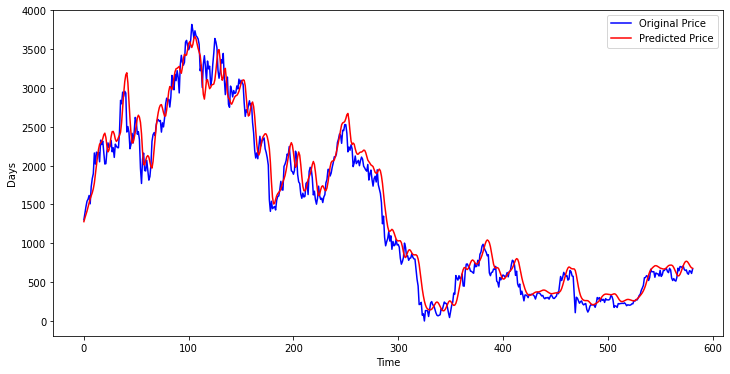

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(y_test, 'b', label = 'Original Price')
plt.plot(y_predicted , 'r' , label = 'Predicted Price')
plt.xlabel('Time')
plt.ylabel('Days')
plt.legend(loc='best')
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test,y_predicted))
print('Test RMSE : %f' % rmse)

Test RMSE : 178.014245


In [ ]:
model.save('modellstm.h5')